In [1]:
from pathlib import Path
import numpy as np, nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pyvista as pv

In [2]:
def load_data(dir: Path):
    img = np.load(dir / "img.npy")
    mask = np.load(dir / "mask.npy")
    # print(f"Loaded {dir.name} with shapes {img.shape}")
    return img, mask

In [4]:
data_dir = Path("data/converted_real")
nb_slices, cmap = 5, ListedColormap([[0]*4, "red", "green", "blue"])

datasets = {
    "3Dircadb1": {
        "imagesTr": ["1", "5", "10", "15", "20"], 
        "labelsTr": ["1", "5", "10", "15", "20"]
    },
    "bvem": {
        "imagesTr": ["mouse_microns-phase2_256-320nm_crop"], 
        "labelsTr": ["mouse_microns-phase2_256-320nm_crop"]
    },
    "cerebrovascular_segmentation_dataset": {
        "imagesTr": ["CereVess_AB10520_0000", "CereVess_AB11235_0000", "CereVess_AB11471_0000"], 
        "labelsTr": ["CereVess_AB10520", "CereVess_AB11235", "CereVess_AB11471"]
    },
    "DeepVess": {
        "imagesTr": ["HaftJavaherian_DeepVess2018_GroundTruthImage"], 
        "labelsTr": ["HaftJavaherian_DeepVess2018_GroundTruthLabel"]
    },
    "HR-Kidney": {
        "imagesTr": ["kidney2"], 
        "labelsTr": ["kidney2"]
    },
    "MiniVess": {
        "imagesTr": ["mv01", "mv10", "mv20", "mv50", "mv60"], 
        "labelsTr": ["mv01", "mv10", "mv20", "mv50", "mv60"]
    },
    "msd_task8": {
        "imagesTr": [
            "hepaticvessel_001", "hepaticvessel_042", 
            "hepaticvessel_092", "hepaticvessel_166", "hepaticvessel_235"
        ], 
        "labelsTr": [
            "hepaticvessel_001", "hepaticvessel_042", 
            "hepaticvessel_092", "hepaticvessel_166", "hepaticvessel_235"
        ]
    },
    "octa": {
        "imagesTr": ["test_set_m4_0", "test_set_m4_1", "test_set_m44_0", "test_set_m78_0"], 
        "labelsTr": ["test_set_m4_0", "test_set_m4_1", "test_set_m44_0", "test_set_m78_0"]
    },
    "TopCoW_ct": {
        "imagesTr": ["topcow_ct_001", "topcow_ct_002", "topcow_ct_003"], 
        "labelsTr": ["topcow_ct_001", "topcow_ct_002", "topcow_ct_003"]
    },
    "TopCoW_mra": {
        "imagesTr": ["topcow_mr_001", "topcow_mr_002", "topcow_mr_003"], 
        "labelsTr": ["topcow_mr_001", "topcow_mr_002", "topcow_mr_003"]
    },
    "tubenet_2Photon": {
        "imagesTr": ["0"], 
        "labelsTr": ["0"]
    },
    "tubenet_MRI": {
        "imagesTr": ["0"], 
        "labelsTr": ["0"]
    },
    "TubeTK": {
        "imagesTr": ["002", "020", "054", "074", "088"], 
        "labelsTr": ["002", "020", "054", "074", "088"]
    },
    "VesselExpress_Bladder": {
        "imagesTr": [
            "B1_210913_details_vessels_13-22-1_1-100", 
            "B1_210913_details_vessels_13-22-1_300x300_250-350z",  
            "B2_210914_details_vessels_10-34-07-1_100-200", 
            "B3_210914_details_vessels_11-07-1_1-100", 
            "B4_210914_details_vessels_11-47-1_1-100"
        ], 
        "labelsTr": [
            "B1_210913_details_vessels_13-22-1_1-100", 
            "B1_210913_details_vessels_13-22-1_300x300_250-350z", 
            "B2_210914_details_vessels_10-34-07-1_100-200", 
            "B3_210914_details_vessels_11-07-1_1-100", 
            "B4_210914_details_vessels_11-47-1_1-100"
        ]
    },
    "VesselExpress_Figure2": {
        "imagesTr": [
            "210426_592-1-lepleft_2000x_VEG", 
            "210426_592-1-lepright_2000x_VEG", 
            "210428_ob593left_2000x_VEG", 
            "210428_ob593right_2000x_VEG"
        ],
        "labelsTr": [
            "210426_592-1-lepleft_2000x_VEG", 
            "210426_592-1-lepright_2000x_VEG",
            "210428_ob593left_2000x_VEG", 
            "210428_ob593right_2000x_VEG"
        ]
    },
    "VesselExpress_Heart": {
        "imagesTr": ["20190109_Basal_LV1", "20190109_Basal_LV2", "20190109_IR5d_LV1"],
        "labelsTr": ["20190109_Basal_LV1", "20190109_Basal_LV2", "20190109_IR5d_LV1"]
    }
}

for dataset in datasets.keys():
    images = datasets[dataset]["imagesTr"]
    labels = datasets[dataset]["labelsTr"]
    fig = plt.figure(figsize=(5*nb_slices, 5*len(images)))
    fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95, wspace=0.05, hspace=0.05)
    axes = fig.subplots(len(images), nb_slices)
    for j, (image, label) in enumerate(zip(images, labels)):
        slices = sorted((data_dir / dataset / "imagesTr" / image).iterdir())
        z = np.linspace(0, len(slices)-2, nb_slices, dtype=int) # on enlève le fichier metadata.json
        for i, zi in enumerate(z):
            img = np.load(data_dir / dataset / "imagesTr" / image / f"{zi:04d}.npy")
            mask = np.load(data_dir / dataset / "labelsTr" / label / f"{zi:04d}.npy")
            axes[j, i].imshow(img, cmap="gray") if len(images) > 1 else axes[i].imshow(img, cmap="gray")
            axes[j, i].imshow(mask, cmap=cmap, alpha=0.5) if len(images) > 1 else axes[i].imshow(mask, cmap=cmap, alpha=0.5)
            axes[0, i].set_title(f"Slice {zi}") if len(images) > 1 else axes[i].set_title(f"Slice {zi}")
        axes[j, 0].set_ylabel(f"Subject {image}") if len(images) > 1 else axes[0].set_ylabel(f"Subject {image}")
    plt.suptitle(f"{dataset} dataset", fontsize=20)
    plt.savefig(f"sauron/converted_real/{dataset}.png", dpi=300)
    plt.close()

In [ ]:
pl = pv.Plotter()
k, out = [1], "sauron/converted_real/3Dircadb1.svg"
for j, kj in enumerate(k):
    img, mask = np.zeros((512, 512, 129)), np.zeros((512, 512, 129))
    for i in range(129):
        slice = np.load(data_dir / "imagesTr" / str(kj) / f"{i:04d}.npy")
        mask_slice = np.load(data_dir / "labelsTr" / str(kj) / f"{i:04d}.npy")
        img[:, :, i] = slice
        mask[:, :, i] = mask_slice

    user_matrix = np.eye(4)
    user_matrix[2, 2] = 1.6000000238418595;    user_matrix[0, 0] = 0.569999992847443;    user_matrix[1, 1] = 0.569999992847443

    pl.add_volume(mask.astype(np.float32), cmap="viridis", opacity="linear", show_scalar_bar=False, user_matrix=user_matrix)
    break
pl.save_graphic(out)
print(f"Saved 3D visualization as {out}")

NameError: name 'data_dir' is not defined

In [8]:
data_dir = Path("data/d_real/3Dircadb1")

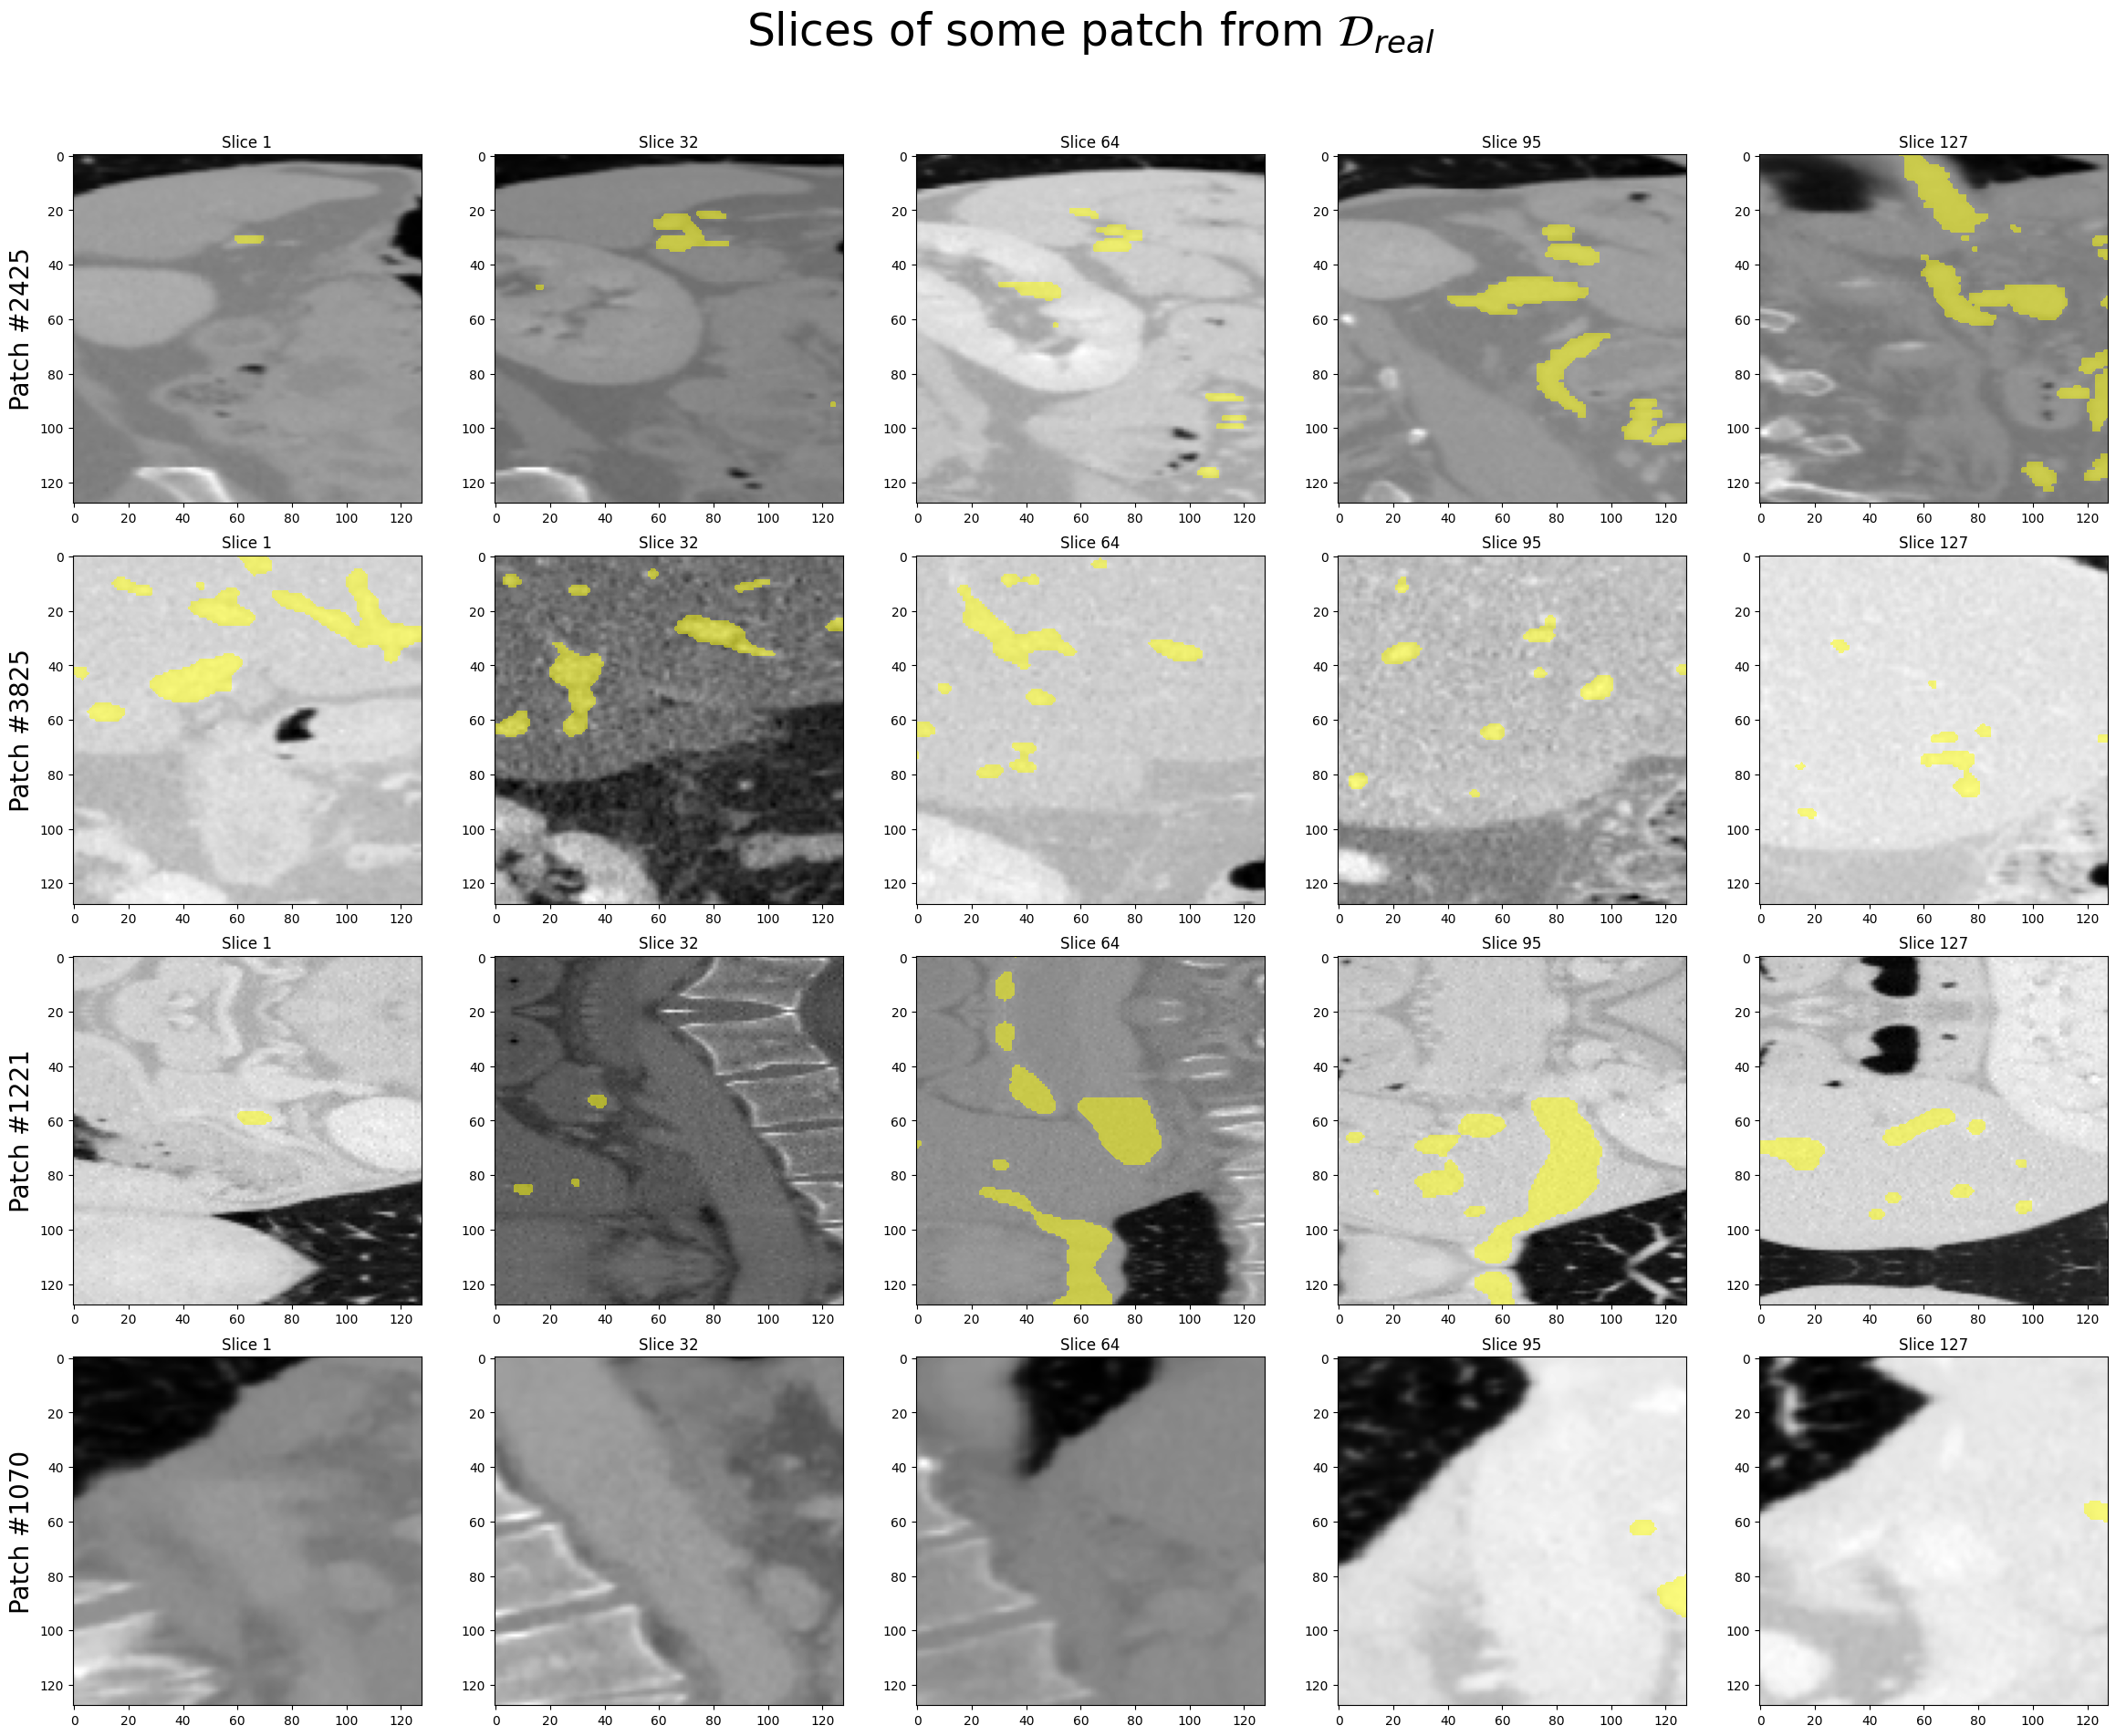

In [9]:
N, M = 4, np.linspace(1, 127, 5, dtype=int)
cmap = ListedColormap([[0, 0, 0, 0], "yellow"]) # RGBA
fig = plt.figure(figsize=(5*len(M), 5*N))
fig.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.05, wspace=0.15, hspace=0.15)
axs = fig.subplots(N, len(M))
dirs = data_dir.iterdir()
for i in range(N):
    dir = next(dirs)
    for j in range(len(M)):
        img, mask = load_data(dir)
        axs[i, j].imshow(img[:, :, M[j]], cmap="gray")
        axs[i, j].imshow(mask[:, :, M[j]], cmap=cmap, alpha=0.5)
        axs[i, j].set_title(f"Slice {M[j]}")
    axs[i, 0].set_ylabel(f"Patch #{dir.name}", fontsize=20)
plt.suptitle("Slices of some patch from $\\mathcal{D}_{real}$", fontsize=35)
plt.savefig("sauron/d_real/3Dircadb1.png", dpi=300)
plt.show()

In [ ]:
pl = pv.Plotter()
N, out = 1, "sauron/d_real/3d.svg"
dirs = data_dir.iterdir()
for i in range(N):
    dir = next(dirs)
    for j in range(len(M)):
        img, mask = load_data(dir)
        pl.add_volume(mask.astype(np.float32), opacity="linear", show_scalar_bar=False)
        break
    break
pl.save_graphic(out)
print(f"3D visualization saved as {out}")

ERROR:root:Unable to open file: /workspace_QMRI/USERS_CODE/hsalles/12_vesselFM/vesselFM/sauron/dreal/3d.svg
2026-06-19 13:48:26.785 ( 312.005s) [    7B320CFE2080]vtkOpenGLGL2PSExporter.:56     ERR| vtkOpenGLGL2PSExporter (0x54da03e0): Unable to open file: /workspace_QMRI/USERS_CODE/hsalles/12_vesselFM/vesselFM/sauron/dreal/3d.svg


3D visualization saved as sauron/dreal/3d.svg


In [11]:
data_dir = Path("data/d_drand/d_drand")

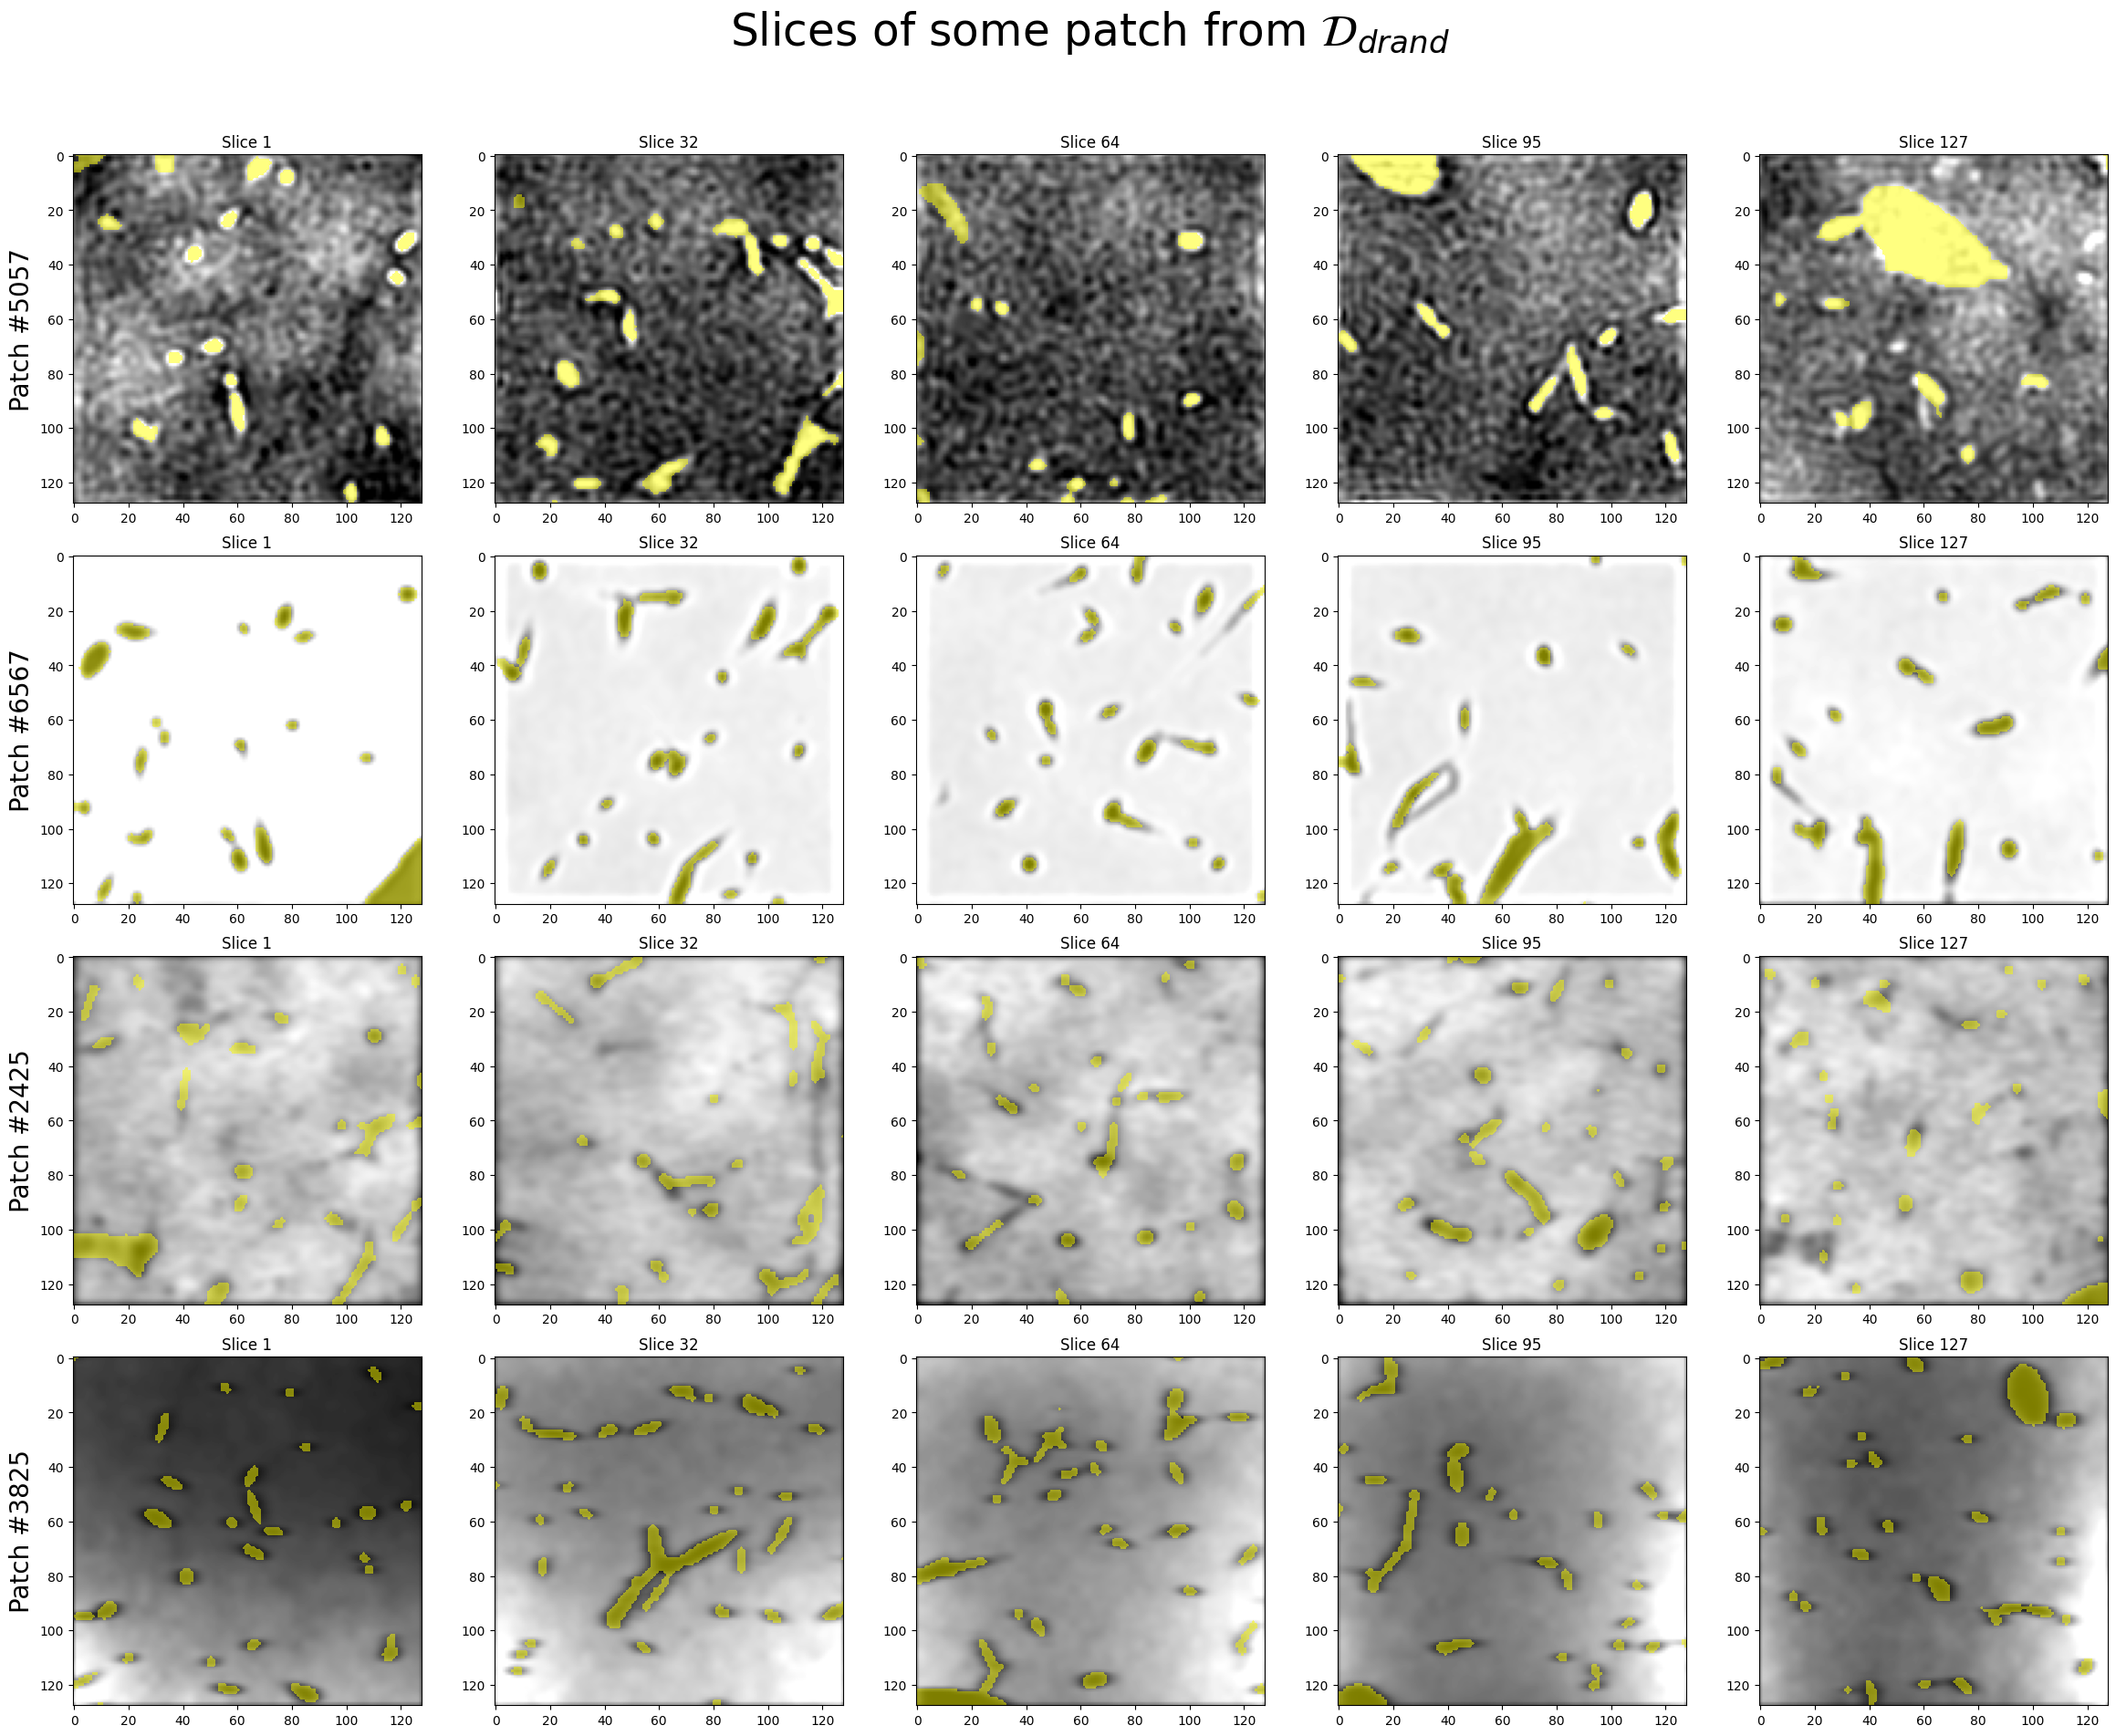

In [ ]:
N, M = 4, np.linspace(1, 127, 5, dtype=int)
cmap = ListedColormap([[0, 0, 0, 0], "yellow"]) # RGBA
fig = plt.figure(figsize=(5*len(M), 5*N))
fig.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.05, wspace=0.15, hspace=0.15)
axs = fig.subplots(N, len(M))
dirs = data_dir.iterdir()
for i in range(N):
    dir = next(dirs)
    for j in range(len(M)):
        img, mask = load_data(dir)
        axs[i, j].imshow(img[:, :, M[j]], cmap="gray")
        axs[i, j].imshow(mask[:, :, M[j]], cmap=cmap, alpha=0.5)
        axs[i, j].set_title(f"Slice {M[j]}")
    axs[i, 0].set_ylabel(f"Patch #{dir.name}", fontsize=20)
plt.suptitle("Slices of some patch from $\\mathcal{D}_{drand}$", fontsize=35)
plt.savefig("sauron/d_drand/patches.png", dpi=300)
plt.show()

In [ ]:
pl = pv.Plotter()
N, out = 1, "sauron/d_drand/3d.svg"
dirs = data_dir.iterdir()
for i in range(N):
    dir = next(dirs)
    for j in range(len(M)):
        img, mask = load_data(dir)
        pl.add_volume(mask.astype(np.float32), opacity="sigmoid", show_scalar_bar=False)
        break
    break
pl.save_graphic(out)
print(f"3D visualization saved as {out}")

2026-06-19 13:48:37.280 ( 322.500s) [    7B320CFE2080]vtkOpenGLGL2PSExporter.:56     ERR| vtkOpenGLGL2PSExporter (0x594ERROR:root:Unable to open file: /workspace_QMRI/USERS_CODE/hsalles/12_vesselFM/vesselFM/sauron/d_rand/3d.svg
63900): Unable to open file: /workspace_QMRI/USERS_CODE/hsalles/12_vesselFM/vesselFM/sauron/d_rand/3d.svg


3D visualization saved as sauron/d_rand/3d.svg


In [14]:
run_dir = Path("runs/fm")

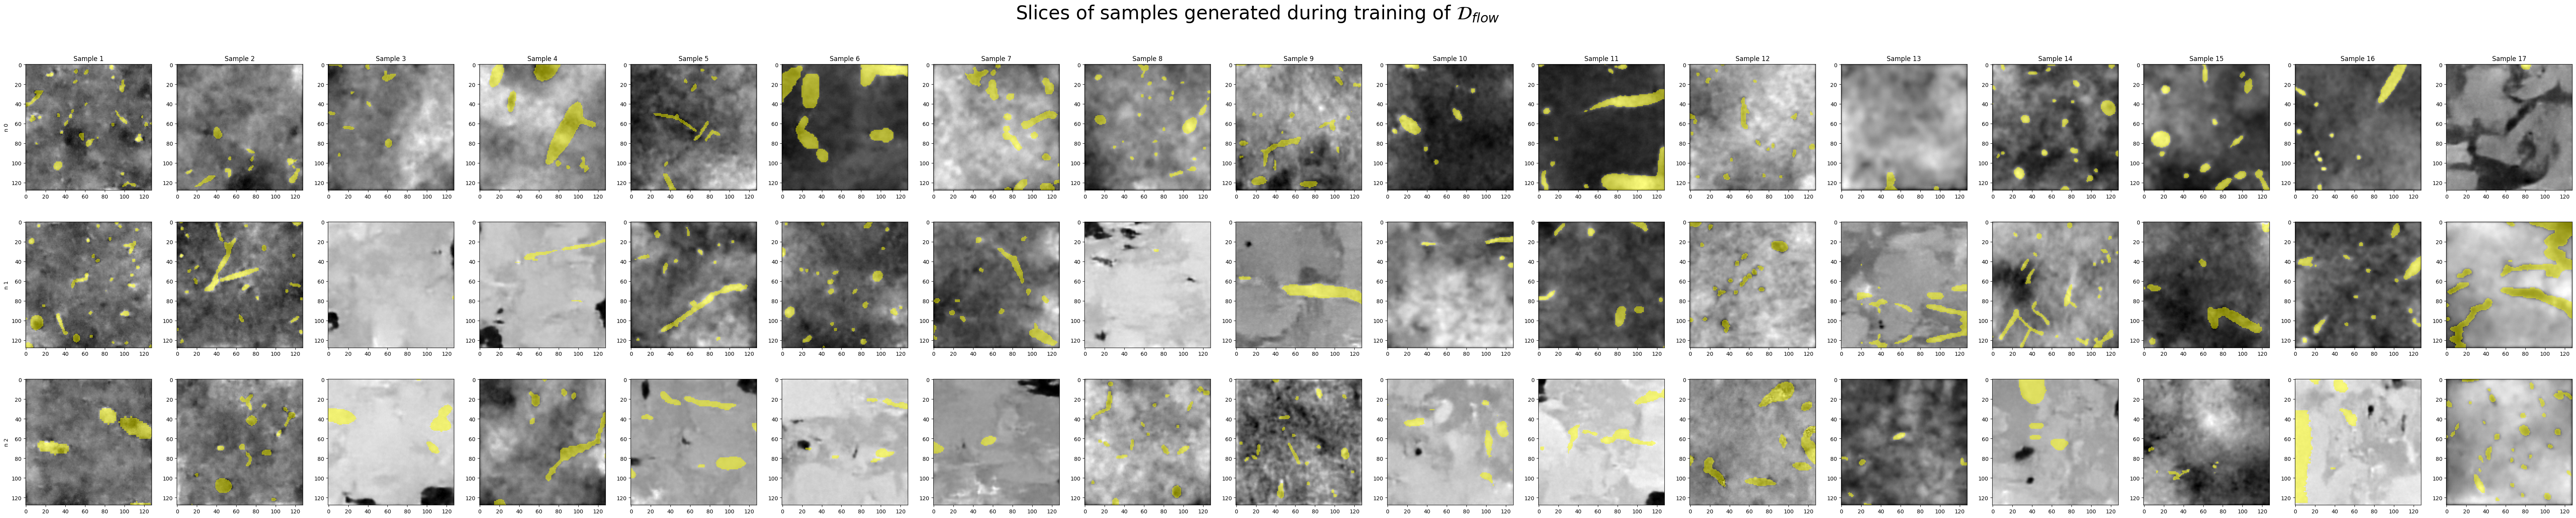

In [15]:
s, i, z, cmap = range(1, 18), [0, 1, 2], 64, ListedColormap([[0, 0, 0, 0], "yellow"]) # RGBA
fig, axes = plt.subplots(len(i), len(s), figsize=(5*len(s), 5*len(i)))
for _i in i:
    for _s in s:
        img = nib.load(next(run_dir.glob(f"sample-{_s}-i-{_i}-class-*.nii.gz"))).get_fdata()[..., z]
        mask = nib.load(next(run_dir.glob(f"sample-{_s}-m-{_i}-class-*.nii.gz"))).get_fdata()[..., z]
        axes[_i, _s-1].imshow(img, cmap="gray")
        axes[_i, _s-1].imshow(mask, cmap=cmap, alpha=0.5)
        axes[0, _s-1].set_title(f"Sample {_s}")
    axes[_i, 0].set_ylabel(f"n {_i}")
plt.suptitle("Slices of samples generated during training of $\\mathcal{D}_{flow}$", fontsize=35)
plt.savefig("sauron/d_flow/diffusion.png", dpi=300)
plt.show()